# SUPPORT2 Dataset: Bayesian Modeling
**AAI-500 Applied Statistics for AI | Final Team Project**

---

## Notebook Objectives

This notebook covers the **Model Selection & Analysis** phase using a **Bayesian Logistic Regression**
implemented in PyMC. We will compare it with another Bayesian model in a subsequent notebook.

**Why Bayesian Logistic Regression?**
- LR is simpliest in explainability and quick to run. Most of our features behaves linearly. Some exception are a few lab values like `bili`, `hrt`, etc
- Unlike regular LR whose coefficients are point estimates, BLR Produces a posterior distribution over each coefficient.
- Provides calibrated uncertainty intervals for every prediction, a necessity for clinical domains.


---
## Section 0: Setup & Imports

In [6]:
import sys
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
from scipy.special import expit as sigmoid
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

_here = Path.cwd()
_proj_root = _here if (_here / "utils").exists() else (_here / "../..").resolve()
if str(_proj_root) not in sys.path:
    sys.path.insert(0, str(_proj_root))

from utils.dataset import load_csv  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---
## Section 1: Load Data & Feature Selection

We select 9 continuous and 2 categorical features based on EDA findings and the
feature-selection experiments in Section 1b below:

| Feature | Type | EDA justification |
|---|---|---|
| `age` | continuous | Non-survivors were ~3 years older on average |
| `meanbp` | continuous | Hemodynamic instability - direct mortality signal |
| `bili` | continuous | Liver/sepsis marker; heavy right-skew with a long high-value tail (high IQR-outlier rate in EDA Section 2), linked with liver failure |
| `bun` | continuous | Kidney function marker |
| `alb` | continuous | Nutritional/liver status; low in high-mortality groups |
| `adlsc` | continuous | Functional status - non-survivors more dependent (2.27 vs 1.55) |
| `scoma` | continuous | SUPPORT coma score - severity of neurological impairment |
| `pafi` | continuous | PaO2/FiO2 ratio (oxygenation); added in Section 1b AUC search |
| `hrt` | continuous | Heart rate; added in Section 1b AUC search |
| `dzclass` | categorical | Strongest categorical predictor (4 disease classes). We use dzclass instead of dzgroup to align with Knaus et al who grouped diagnoses with similarly-shpaed survival curves |
| `ca` | categorical | Cancer status (no/yes/metastatic); added in Section 1b AUC search |

---
## Section 1b: Feature Selection Experimentation

We use 11 features for our modeling 

**TODO**: explain feature selection experiments

### Handling categorical features
In order for regression models to work on categorical features, we need to one-hot encode them.
This prevents strict multicollinearity (dummy variable trap)

- **dzclass**: We drop the first disease class `ARF/MOSF` and use it as a baseline reference
- **ca**: We drop metastatic and use it as the baseline cancer status

In [10]:
df = load_csv("support2_cleaned.csv")
print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")

TARGET_COL = "death_180d"
CONT_FEATURES = ["age", "meanbp", "bili", "bun", "alb", "adlsc", "scoma", "pafi", "hrt"]

# reorganize so we can use cancer=no as baseline which makes the forest plot more sensible
df["ca"] = pd.Categorical(df["ca"], categories=["no", "yes", "metastatic"])

## Handling Categorical classes

# One-hot encode dzclass (drop first level = ARF/MOSF as reference)
dzclass_dummies = pd.get_dummies(df["dzclass"], prefix="dzclass", drop_first=True)
# One-hot encode cancer status (drop "ca_no", first alphabetically, as reference)
ca_dummies = pd.get_dummies(df["ca"], prefix="ca", drop_first=True)
DUMMY_COLS = list(dzclass_dummies.columns) + list(ca_dummies.columns)
FEATURE_NAMES = CONT_FEATURES + DUMMY_COLS

print(f"\ndzclass reference level: ARF/MOSF")
print(f"ca reference level: ca_no")
print(f"Dummy columns: {DUMMY_COLS}")
print(f"Total features: {len(FEATURE_NAMES)}")

df_model = pd.concat(
    [df[CONT_FEATURES + [TARGET_COL]], dzclass_dummies, ca_dummies], axis=1
)
print(f"\nClass balance:")
print(df_model[TARGET_COL].value_counts().rename({0: "Survived", 1: "Died"}))

Shape: 9,105 rows  x  42 columns

dzclass reference level: ARF/MOSF
ca reference level: ca_no
Dummy columns: ['dzclass_COPD/CHF/Cirrhosis', 'dzclass_Cancer', 'dzclass_Coma', 'ca_yes', 'ca_metastatic']
Total features: 14

Class balance:
death_180d
Survived    4840
Died        4265
Name: count, dtype: int64


---
## Section 2: Preprocessing

### Standardizing
To make the features more comparable we employ standardization.
Here we rescale our continuous features coefficients using **z-score standardized**: 

$$z = \frac{x - \bar{x}}{s}$$

This centers each feature at mean 0 and rescale by a standard deviation of 1.

### Data Splitting
Then we do a 80/20 stratified split on the dataset, where 80% is used for training and 20% for testing. We picked 80/20 instead of the better 3-way split with K-fold cross-validation as it's simpler and apt for this small project.


In [11]:
X_cont = df_model[CONT_FEATURES].values
X_cat = df_model[DUMMY_COLS].values.astype(float)
y = df_model[TARGET_COL].values

# Standardize continuous features only
scaler = StandardScaler()
X_std = np.column_stack([scaler.fit_transform(X_cont), X_cat])
n_feat = X_std.shape[1]

# Stratified 80/20 split
idx_all = np.arange(len(df_model))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_std, y, idx_all, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Train: {len(y_train):,}  |  Test: {len(y_test):,}")
print(
    f"Train prevalence: {y_train.mean():.1%}  |  Test prevalence: {y_test.mean():.1%}"
)

# Descriptive stats of standardized features
feat_stats = pd.DataFrame(X_train, columns=FEATURE_NAMES).describe().T
feat_stats[["mean", "std", "min", "max"]]

Train: 7,284  |  Test: 1,821
Train prevalence: 46.8%  |  Test prevalence: 46.8%


,mean,std,min,max
age,-0.006,1.003,-2.861,2.450
meanbp,0.005,1.002,-3.054,3.990
bili,0.002,1.006,-0.443,13.386
bun,0.007,1.014,-0.817,12.036
alb,-0.000,1.013,-3.702,34.742
adlsc,-0.004,0.998,-0.942,2.588
scoma,0.000,1.002,-0.489,3.570
pafi,-0.001,1.003,-2.323,6.082
hrt,-0.010,0.999,-3.079,4.273
dzclass_COPD/CHF/Cirrhosis,0.314,0.464,0.000,1.000


---
## Section 3: Prior Predictive Check

A prior represent our assumptions about the model's parameters before training.
A good prior should produce predicted probabilities spread across [0, 1]
rather than collapsing near 0 or 1.

Here we do a quick check to see if our priors are reasonable. 

**Histogram shows a nice spread confirming that our features are nicely calibrated **

**Prior specification:**
- Intercept: `Normal(0, 2)`: gives a wide range, with baseline mortality probabilities between 2% ~ 98%
- Coefficients: `Normal(0, 1)`:  penalize one feature from making a large impact. We assume in biology it's implausible for one lab metric to cause death.

Sampling: [betas, intercept, obs]


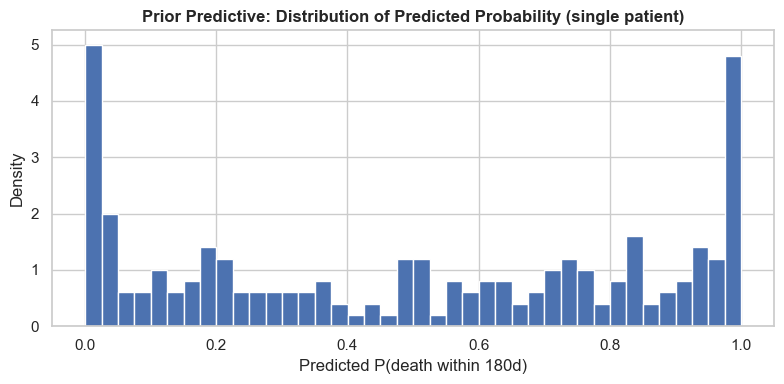

In [ ]:
with pm.Model() as bayes_lr:
    X_data = pm.Data("X_data", X_train)

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=2)
    betas = pm.Normal("betas", mu=0, sigma=1, shape=n_feat)

    # Linear predictor + sigmoid link
    logit_p = intercept + pm.math.dot(X_data, betas)
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    # Likelihood
    obs = pm.Bernoulli("obs", p=p, observed=y_train)

    prior_pred = pm.sample_prior_predictive(draws=200, random_seed=RANDOM_SEED)

prior_p = prior_pred.prior["p"].values.reshape(-1, len(y_train))
sample_probs = prior_p[:500, 0]  # distribution for one patient

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_probs, bins=40, edgecolor="white", density=True)
ax.set_title(
    "Prior Predictive: Distribution of Predicted Probability (single patient)",
    fontweight="bold",
)
ax.set_xlabel("Predicted P(death within 180d)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

---
## Section 4: Model Training (MCMC - NUTS Sampler)

Sampling is special to Bayesian as it's done to quantify uncertainty. 
Unlike gradient descent which finds a single best sets of weights, Bayesian samples a thousand sets of weights.

We use the **No-U-Turn Sampler (NUTS)**, a popular gradient-based MCMC algorithm that
efficiently explores high-dimensional posterior distributions.

**What is NUTS?**

The No-U-Turn Sampler (NUTS) is an advanced, physics-inspired algorithm for mapping out probability distributions. If traditional sampling is a blindfolded person taking random steps to explore a valley, NUTS removes the blindfold. It calculates the physical slope of the valley (gradients) to glide smoothly and directly toward the highest probability areas, automatically stopping the exact moment before it wastes time looping back over its own path (the "No-U-Turn").

**Why we chose it?**

 * Speed in High Dimensions: With 14 distinct features, standard samplers get easily stuck or take far too long. NUTS uses gradients to scale efficiently across complex, multi-variable models.
 * Zero Manual Tuning: Older algorithms require you to manually guess and calibrate the "step size" of the sampler. NUTS automatically adapts its own parameters on the fly during its warm-up phase.
 * Higher Quality Samples: Because of its smooth, calculated trajectories, the samples it generates are less correlated. This gives us a much more accurate and mathematically robust picture of our model's true uncertainty.

**Sampling parameters:**

**TODO**: tweak and optimize

- `draws=1000`: posterior samples per chain
- `tune=1000`: warm-up/adaptation steps (discarded)
- `chains=4`: independent chains for convergence diagnostics
- `target_accept=0.9`: acceptance rate target (reduces divergences)

In [ ]:
with bayes_lr:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )
print("Sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, betas]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


Sampling complete.


---
## Section 5: Sanity Check on NUTS Sampler

**Key convergence diagnostics:**

| Metric | Good threshold | Meaning | Our Results
|---|---|---|--|
| **R-hat** | < 1.01 | Chains converged to the same distribution | Good
| **ESS bulk** | > 400 | Effective sample size - independent posterior draws | Good
| **Divergences** | 0 | physics error | Good


In [ ]:
summary = az.summary(trace, var_names=["intercept", "betas"])
summary.index = ["intercept"] + FEATURE_NAMES
# Column names in ArviZ 1.1: eti89_lb / eti89_ub (89% equal-tailed interval)
diag_cols = [
    c
    for c in ["mean", "sd", "eti89_lb", "eti89_ub", "r_hat", "ess_bulk"]
    if c in summary.columns
]
print(summary[diag_cols].to_string())
print(f"\nDivergences: {trace.sample_stats.diverging.values.sum()}")

                               mean      sd eti89_lb eti89_ub r_hat  ess_bulk
intercept                    -0.313  0.0421    -0.38    -0.25  1.00      4789
age                          0.2711  0.0274     0.23     0.32  1.00      6207
meanbp                      -0.1239  0.0269    -0.17    -0.08  1.00      7333
bili                         0.1932    0.03     0.15     0.24  1.00      6115
bun                          -0.042  0.0257   -0.083  -0.0013  1.00      6976
alb                         -0.0433  0.0284   -0.089   0.0022  1.00      8241
adlsc                        0.3083  0.0261     0.27     0.35  1.00      6662
scoma                          0.59   0.037     0.53     0.65  1.00      5229
pafi                        -0.0537  0.0277   -0.098  -0.0093  1.00      7466
hrt                          0.1136  0.0281    0.069     0.16  1.00      6469
dzclass_COPD/CHF/Cirrhosis   -0.377   0.063    -0.48    -0.28  1.00      5015
dzclass_Cancer               -0.476   0.139     -0.7    -0.25  1

### Sampling Plots
Another sanity check: We plot the traces of what we we predict are to be the most impactful features

**Trace Plots**:

`Healthy`. We're looking for overlapping of the 4 chains, dense and flat. No spikes and independent lines

**Distribution Plots**

`Healthy`. Bell shape means it's balanced and calibrated. No high peaks (overconfidence) or big spread (noisy)


- **SCOMA, Metastatic** - positive so model is very confident this leads to death


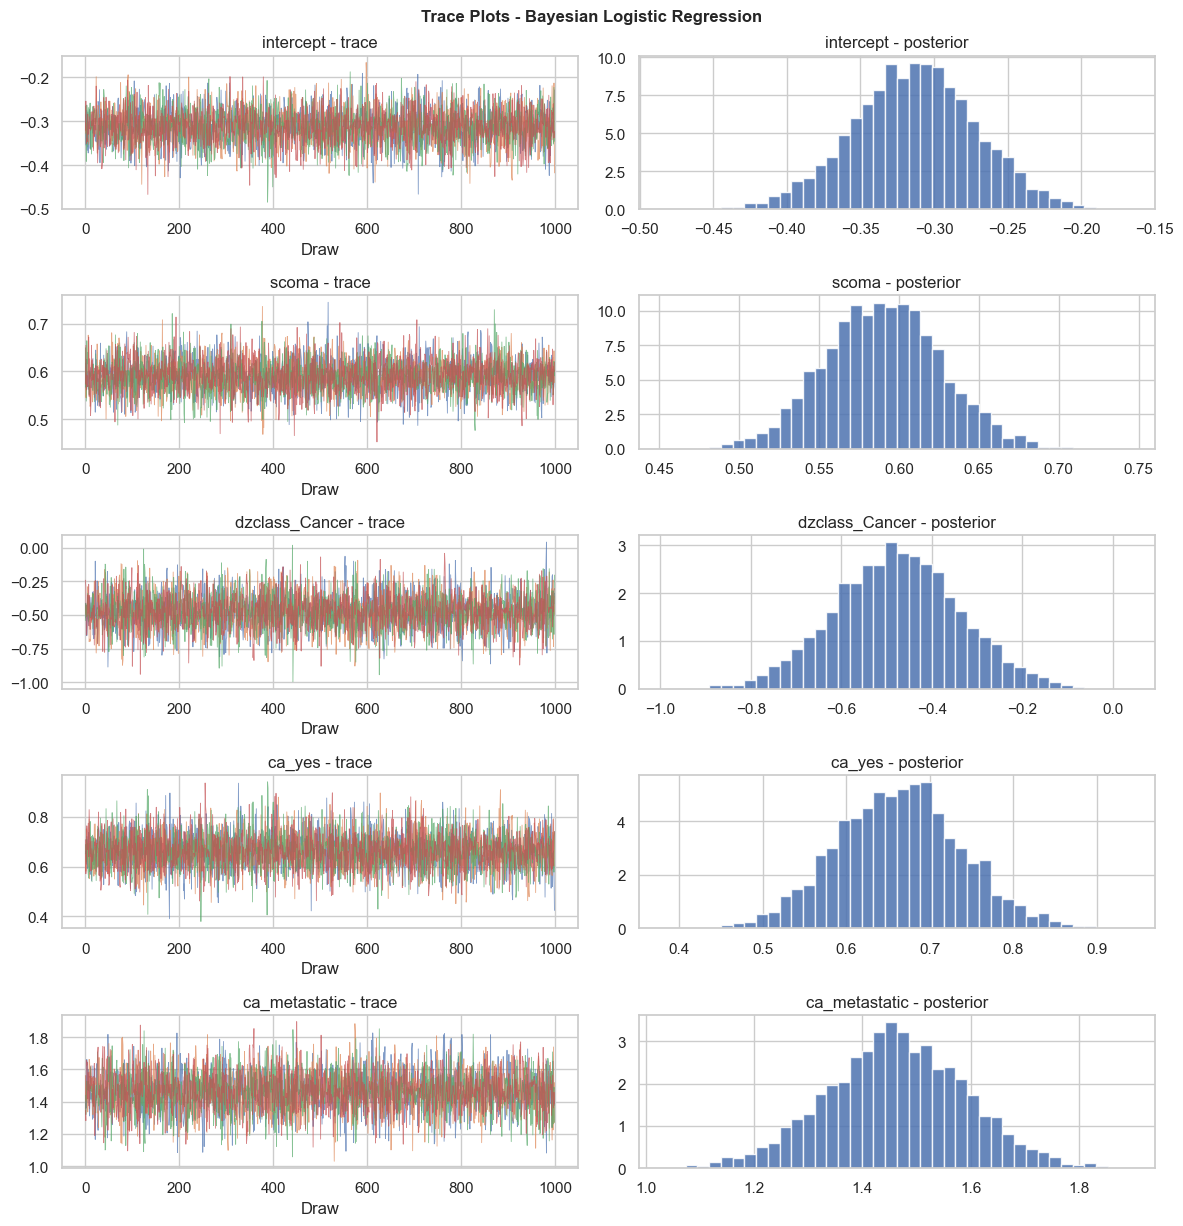

In [ ]:
post_int = trace.posterior["intercept"].values  # (chains, draws)
post_b = trace.posterior["betas"].values  # (chains, draws, n_feat)
show_vars = [
    "intercept",
    "scoma",
    "dzclass_Cancer",
    "ca_yes",
    "ca_metastatic",
]  # largest-effect predictors

fig, axes = plt.subplots(len(show_vars), 2, figsize=(12, 2.5 * len(show_vars)))
for row, name in enumerate(show_vars):
    if name == "intercept":
        samples = post_int
    else:
        fidx = FEATURE_NAMES.index(name)
        samples = post_b[:, :, fidx]
    # Trace
    for chain_idx in range(samples.shape[0]):
        axes[row, 0].plot(samples[chain_idx], alpha=0.7, linewidth=0.6)
    axes[row, 0].set_title(f"{name} - trace")
    axes[row, 0].set_xlabel("Draw")
    # Posterior distribution
    axes[row, 1].hist(
        samples.flatten(),
        bins=40,
        edgecolor="white",
        density=True,
        alpha=0.85,
    )
    axes[row, 1].set_title(f"{name} - posterior")

fig.suptitle(
    "Trace Plots - Bayesian Logistic Regression", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

---
## Section 6: Posterior Coefficient Analysis

The **94% Highest Density Interval (HDI)** is the Bayesian analogue of a confidence interval.
In the forest plot below:
* dot: mean of posterior distribution
* line: 94% Highest Density Interval. Effectively saying "We are confident 94% of true weights falls within this line"

**Reading the forest plot**
- If the HDI **excludes 0**: the feature has a credible effect on mortality
- Positive coefficient: higher value → higher mortality probability
- Negative coefficient: higher value → lower mortality probability

Coefficients are on **standardized** continuous features: a coefficient of 1.0 means
a 1-SD increase changes the log-odds by 1.0 (≈ 2.7× odds multiplier).

**Results Interpretation**
- `scoma`: strongest risk factor
- `ca_no, ca_yes, dzclass_Cancer, dzclass_COPD`: negative effect on mortality due to our Dummy Encoding, which is relative to metastastic
- `dzclass_Coma, bun, alb`: uncertain predictors

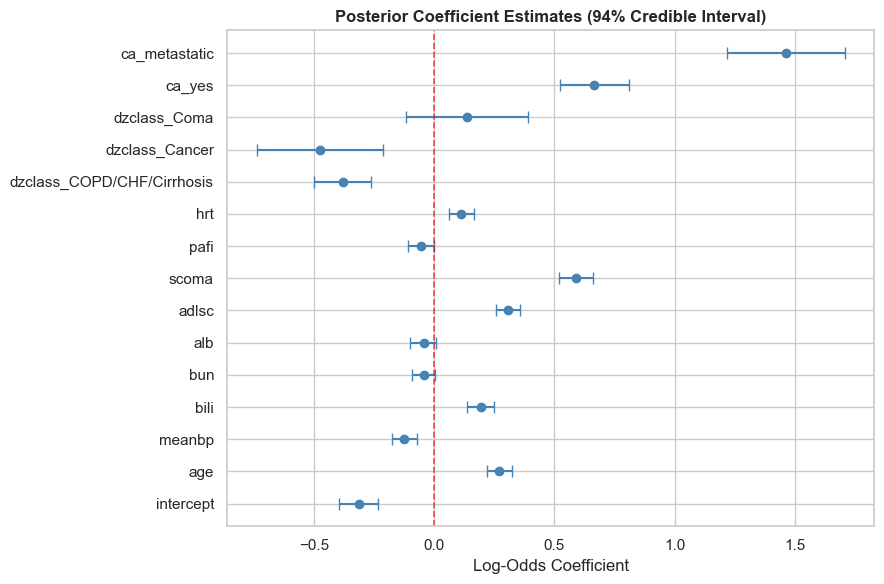

In [ ]:
# Manual forest plot using posterior arrays
post_int_flat = trace.posterior["intercept"].values.flatten()
post_b_flat = trace.posterior["betas"].values.reshape(-1, n_feat)

all_names = ["intercept"] + FEATURE_NAMES
means_all = [post_int_flat.mean()] + list(post_b_flat.mean(axis=0))
lower_all = [np.percentile(post_int_flat, 3)] + list(
    np.percentile(post_b_flat, 3, axis=0)
)
upper_all = [np.percentile(post_int_flat, 97)] + list(
    np.percentile(post_b_flat, 97, axis=0)
)

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = range(len(all_names))
ax.errorbar(
    means_all,
    y_pos,
    xerr=[
        np.array(means_all) - np.array(lower_all),
        np.array(upper_all) - np.array(means_all),
    ],
    fmt="o",
    color="steelblue",
    ecolor="steelblue",
    capsize=4,
    markersize=6,
    elinewidth=1.5,
)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(all_names)
ax.set_title(
    "Posterior Coefficient Estimates (94% Credible Interval)", fontweight="bold"
)
ax.set_xlabel("Log-Odds Coefficient")
plt.tight_layout()
plt.show()

In [ ]:
# Odds ratios from posterior means
post_betas = trace.posterior["betas"].values.reshape(-1, n_feat)
or_mean = np.exp(post_betas.mean(axis=0))
or_lower = np.exp(np.percentile(post_betas, 3, axis=0))
or_upper = np.exp(np.percentile(post_betas, 97, axis=0))

or_df = pd.DataFrame(
    {
        "Feature": FEATURE_NAMES,
        "OR Mean": or_mean.round(3),
        "OR 5.5% ETI": or_lower.round(3),
        "OR 94.5% ETI": or_upper.round(3),
        "Direction": ["Higher risk" if v > 1 else "Lower risk" for v in or_mean],
    }
).sort_values("OR Mean", ascending=False)

print("Odds Ratios (per 1 SD change for continuous features):")
print(or_df.to_string(index=False))

Odds Ratios (per 1 SD change for continuous features):
                   Feature  OR Mean  OR 5.5% ETI  OR 94.5% ETI   Direction
             ca_metastatic    4.313        3.376         5.513 Higher risk
                    ca_yes    1.941        1.688         2.247 Higher risk
                     scoma    1.804        1.684         1.935 Higher risk
                     adlsc    1.361        1.295         1.429 Higher risk
                       age    1.311        1.246         1.382 Higher risk
                      bili    1.213        1.148         1.284 Higher risk
              dzclass_Coma    1.147        0.890         1.480 Higher risk
                       hrt    1.120        1.063         1.182 Higher risk
                       bun    0.959        0.914         1.005  Lower risk
                       alb    0.958        0.906         1.009  Lower risk
                      pafi    0.948        0.899         0.998  Lower risk
                    meanbp    0.883        0.

**Note on `dzclass_Cancer`:** show's lower risk due to a collinearity effect. It represents the **residual** effect, not the standalone cancer risk. For example, pure lung/colon-cancer group has somewhat lower mortality than metastatic patients who are also have organ failure. 

---
## Section 7: Posterior Predictive Check

Similar to our Prior check, we now ask "Now that the model has learned from the data, can it accurately simulate reality". This is known as a Posterior Predictive Check (PPC).

To do this, we ask the trained model to generate new, simulated outcomes ("survived or "died") for every patient in the dataset, using the weights it just learned. If the model is well-calibrated, this simulated data should be statistically the same from the original data.

**Result**: The observed rate at 46.8% matches with the original died:survived ratio (4265:4840)

Sampling: [obs]


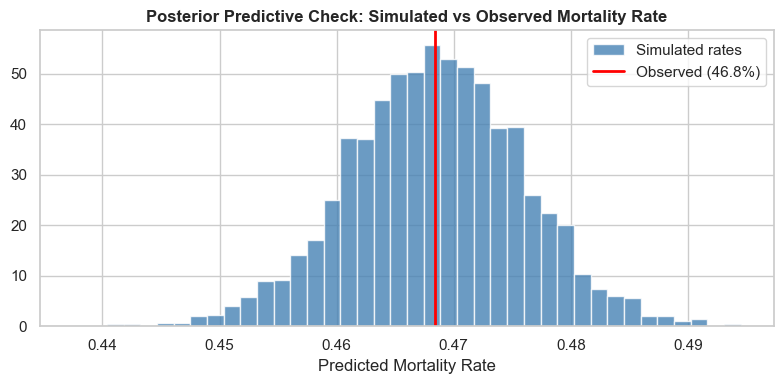

In [ ]:
with bayes_lr:
    ppc = pm.sample_posterior_predictive(trace, random_seed=RANDOM_SEED)

# Compare simulated vs observed mortality rate
sim_rates = (
    ppc.posterior_predictive["obs"].values.reshape(-1, len(y_train)).mean(axis=1)
)
obs_rate = y_train.mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    sim_rates,
    bins=40,
    color="steelblue",
    edgecolor="white",
    density=True,
    alpha=0.8,
    label="Simulated rates",
)
ax.axvline(obs_rate, color="red", linewidth=2, label=f"Observed ({obs_rate:.1%})")
ax.set_title(
    "Posterior Predictive Check: Simulated vs Observed Mortality Rate",
    fontweight="bold",
)
ax.set_xlabel("Predicted Mortality Rate")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 8: Model Evaluation & Benchmark Comparison

We evaluate the model on the held-out test set (20% of data) using **ROC-AUC**,
and compare against the legacy SUPPORT model benchmark (`surv6m`).

**Baselines to beat (from EDA Section):**
- SUPPORT model (`surv6m`): AUC ≈ 0.789
- Physician estimate (`prg6m`): AUC ≈ 0.756
- APACHE III (`aps`): AUC ≈ 0.658

In [ ]:
# Compute posterior predictive probabilities on test set
post_intercept = trace.posterior["intercept"].values.flatten()
post_betas_all = trace.posterior["betas"].values.reshape(-1, n_feat)

# logit_p for each test patient: shape (n_posterior_samples, n_test)
logits_test = post_intercept[:, None] + post_betas_all @ X_test.T
probs_test = sigmoid(logits_test)

pred_mean = probs_test.mean(axis=0)
pred_lower = np.percentile(probs_test, 3, axis=0)
pred_upper = np.percentile(probs_test, 97, axis=0)

# AUC - our Bayesian model
auc_bayes = roc_auc_score(y_test, pred_mean)

# AUC - legacy surv6m benchmark
surv6m_test = df.iloc[idx_test]["surv6m"].values
auc_surv6m = roc_auc_score(y_test, 1 - surv6m_test)
prg6m_test = df.iloc[idx_test]["prg6m"].values
auc_prg6m = roc_auc_score(y_test, 1 - prg6m_test)
aps_test = df.iloc[idx_test]["aps"].values
auc_aps = roc_auc_score(y_test, aps_test)

print("=== AUC Comparison ===")
print(f"Bayesian LR (our model) : {auc_bayes:.3f}")
print(f"SUPPORT model (surv6m)  : {auc_surv6m:.3f}")
print(f"Physician (prg6m)       : {auc_prg6m:.3f}")
print(f"APACHE III (aps)        : {auc_aps:.3f}")

=== AUC Comparison ===
Bayesian LR (our model) : 0.737
SUPPORT model (surv6m)  : 0.790
Physician (prg6m)       : 0.749
APACHE III (aps)        : 0.663


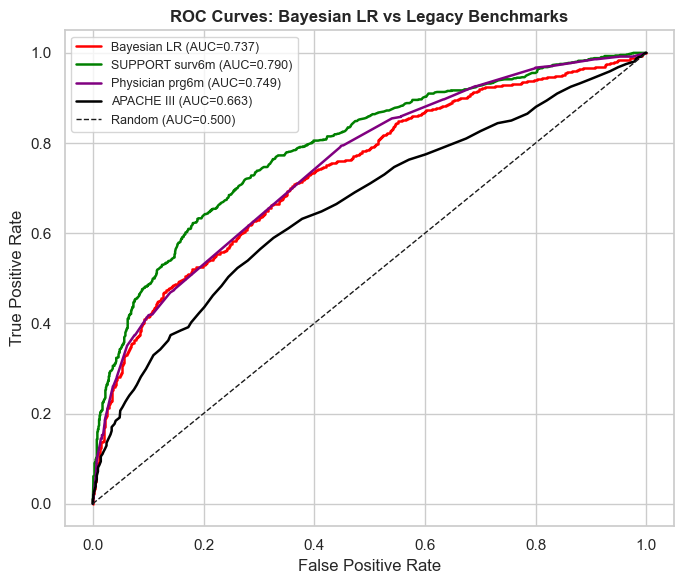

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

# Swapped to a distinct, colorblind-friendly palette
for pred, label, color in [
    (pred_mean, f"Bayesian LR (AUC={auc_bayes:.3f})", "red"),
    (1 - surv6m_test, f"SUPPORT surv6m (AUC={auc_surv6m:.3f})", "green"),
    (1 - prg6m_test, f"Physician prg6m (AUC={auc_prg6m:.3f})", "purple"),
    (aps_test, f"APACHE III (AUC={auc_aps:.3f})", "black"),
]:
    fpr, tpr, _ = roc_curve(y_test, pred)
    # ADDED: color=color
    ax.plot(fpr, tpr, color=color, label=label, linewidth=1.8)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: Bayesian LR vs Legacy Benchmarks", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()